# **Car Purchase Propensity Prediction - Aplicando XGboost**

Nessa atividade será usada uma base de propensão a compra de carros.
O objetivo é desenvolver um modelo de Machine Learning para identificação de clientes com maior probabilidade de compra de veículos, envolvendo análise exploratória, tratamento de dados, treinamento e comparação entre modelos SVM e XGBoost, com avaliação por métricas de classificação e análise de performance.



In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from xgboost import plot_importance
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# Carregando a base de dados
df = pd.read_csv('CARRO_CLIENTES.csv')
df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
# Verificar os tipo de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [4]:
# Verificar dados faltantes
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
AnnualSalary,0
Purchased,0


In [5]:
# Dropar a coluna ID
df.drop('User ID', axis=1, inplace=True)

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [6]:
# Aplicar Label Encorder para coluna Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,Gender,Age,AnnualSalary,Purchased
0,1,35,20000,0
1,1,40,43500,0
2,1,49,74000,0
3,1,40,107500,1
4,1,25,79000,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

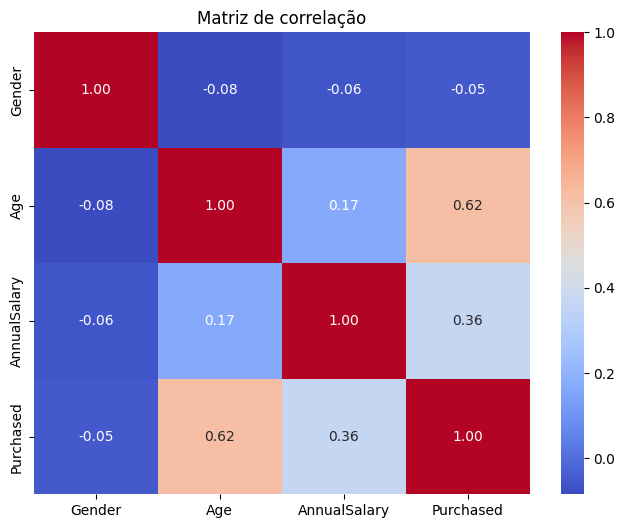

In [18]:
# Matriz de correlacao
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Matriz de correlação')
plt.savefig('matriz_correlacao.png')
plt.show()

A análise da matriz de correlação indicou que a variável *Age* apresentou a maior associação linear com a variável avo *Purchased* (0.62), seguida de *AnnualSalary* (0.36). Esse resultado sugere que renda anual e idade podem influenciar a propensão à compra de veículos. Entretanto, como o XGboost é capaz de capturar relações não lineares e interações entre as variáveis, variáveis com menor correlação foram mantidas para avaliação do modelo.




# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [8]:
# Separação de base em X e Y
X = df.drop('Purchased', axis=1)
Y = df['Purchased']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [10]:
# Treinar o modelo XGboost
modelo_xgboost = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [11]:
modelo_xgboost.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [12]:
# Probabilidade de cada classe
Y_prob = modelo_xgboost.predict_proba(X_test)
print("Primeiras 10 probabilidades:")
print(Y_prob[:10])


Primeiras 10 probabilidades:
[[7.6867628e-01 2.3132375e-01]
 [1.8980086e-02 9.8101991e-01]
 [9.9930888e-01 6.9111527e-04]
 [6.3168293e-01 3.6831707e-01]
 [2.8243566e-01 7.1756434e-01]
 [1.4631373e-01 8.5368627e-01]
 [8.5253716e-03 9.9147463e-01]
 [9.9732083e-01 2.6791592e-03]
 [9.8726988e-01 1.2730108e-02]
 [9.5461243e-01 4.5387544e-02]]


[7.6867628e-01]: Aproximadamente 0.7686, que é probabilidade de a amostra pertencer à classe 0 (não compra)


[2.3132375e-01]: Aproximadamente 0.2313, que é a probabilidade de a amostra pertecncer à classe 1 (compra)

E assim sucessivamente..

In [13]:
# Probabilidade apenas da classe "compra = 1"
Y_prob_compra = modelo_xgboost.predict_proba(X_test)[:, 1]
print("Primeiras 10 probabilidades de compra:")
print(Y_prob_compra[:10])

Primeiras 10 probabilidades de compra:
[2.3132375e-01 9.8101991e-01 6.9111527e-04 3.6831707e-01 7.1756434e-01
 8.5368627e-01 9.9147463e-01 2.6791592e-03 1.2730108e-02 4.5387544e-02]


In [14]:
# Previsões finais (0 ou 1 )
Y_pred = modelo_xgboost.predict(X_test)
print("Primeiras 10 previsões:")
print(Y_pred[:10])

Primeiras 10 previsões:
[0 1 0 0 1 1 1 0 0 0]


In [15]:
# Medir o desempenho
accuracy = accuracy_score(Y_test, Y_pred)
print("Acurácia do modelo:", accuracy)
print(classification_report(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))

Acurácia do modelo: 0.91
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       112
           1       0.93      0.86      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

[[106   6]
 [ 12  76]]


O modelo XGBoost apresentou acurácia de 91%, indicando elevado desempenho na classificação da propensão à compra. A matriz de confusão mostrou 182 classificações corretas em 200 registros avaliados. O modelo alcançou precisão de 93% para identificar compradores e recall de 86%, demostrando boa capacidade de encontrar clientes com potencial de compra.

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [16]:
# Acredito que a questão 6 já respondeu essa requisição

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

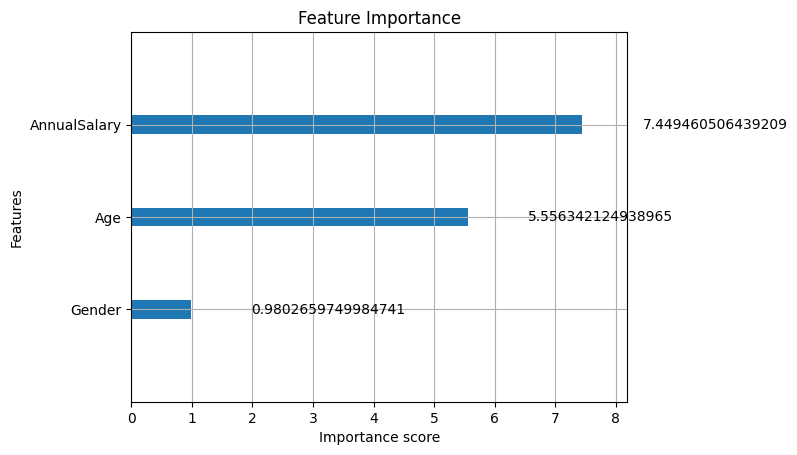

In [19]:
# Trazer a lista com feature importance

plot_importance(
    modelo_xgboost,
    importance_type='gain',
    title='Feature Importance')
plt.savefig('feature_importance.png')

plt.show()

A análise de importância das variáveis mostrou que *AnnualSalary* apresentou maior contribuição para o modelo *XGBoost*, seguida por *Age*. Apesar de *Age* ter apresentado a maior correlação linear com a variável alvo na etapa exploratória, na matriz de correlação, o XGBoost identificou que a renda anual teve maior impacto na redução do erro do modelo. Isso reforça que modelos baseados em àrvores conseguem capturar relações e interações mais complexas entre variáveis.